# Active Systems Confined within Meshes

**CURRENT TUTORIAL STATUS:**
- currently just a copy and paste of personal learning document
    - from Philipp.
    - W/ personal notes I added while llearninG how to use
- probably want to add something to tell abt rigid bodies
    - since intro to active particles were jsut spherse.
    - (also now rotational dof int = TRUE)
- Also right now, relies on outside utility.py file which contains misc functions that were shown more explicitly in previous one.
    - shoudl I combine into 1?
    - or is it better simpler? 

## Overview

### Questions

* 

### Objectives

* Integrate basic mesh with active particles inside



## Boilerplate Code

In [1]:
import math
import numpy as np
import mpl_toolkits.mplot3d
import matplotlib.pyplot as plt
from IPython import display
import time
import gsd.hoomd
import hoomd
import matplotlib
%matplotlib inline
matplotlib.style.use('ggplot')
import matplotlib_inline
import itertools 
import freud
import pandas as pd
from stl import mesh
import fresnel
import random
import pyvista as pv
from utility import fibonacci_sphere, get_active_pos_A, calc_tether_bond_lengths, plot_tether_energies, find_mesh_radius_avg_and_std

The `render` function in the next (hidden) cell will render a snapshot using **fresnel**. Find the source in the [hoomd-examples](https://github.com/glotzerlab/hoomd-examples) repository.

In [2]:
# This is not intended as a full tutorial on fresnel - see the fresnel user
# documentation (https://fresnel.readthedocs.io/) if you would like to learn more.

import warnings

import fresnel
import IPython
import packaging.version

device = fresnel.Device()
tracer = fresnel.tracer.Path(device=device, w=300, h=300)

FRESNEL_MIN_VERSION = packaging.version.parse("0.13.0")
FRESNEL_MAX_VERSION = packaging.version.parse("0.14.0")


def render(snapshot):
    if ('version' not in dir(fresnel) or packaging.version.parse(
            fresnel.version.version) < FRESNEL_MIN_VERSION
            or packaging.version.parse(
                fresnel.version.version) >= FRESNEL_MAX_VERSION):
        warnings.warn(
            f"Unsupported fresnel version {fresnel.version.version} - expect errors."
        )
    central_color = fresnel.color.linear([252 / 255, 41 / 255, 0 / 255])

    L = snapshot.configuration.box[0]
    scene = fresnel.Scene(device)
    geometry = fresnel.geometry.Sphere(scene,
                                       N=len(snapshot.particles.position),
                                       radius=0.5)
    geometry.material = fresnel.material.Material(color=[0, 0, 0],
                                                  roughness=0.5,
                                                  primitive_color_mix=1.0)
    geometry.position[:] = snapshot.particles.position[:]
    geometry.color[snapshot.particles.typeid[:] == 0] = central_color
    geometry.radius[snapshot.particles.typeid[:] == 0] = 0.25
    geometry.outline_width = 0.01
    box = fresnel.geometry.Box(scene, [L, L, L, 0, 0, 0], box_radius=.02)

    scene.lights = [
        fresnel.light.Light(direction=(0, 0, 1),
                            color=(0.8, 0.8, 0.8),
                            theta=np.pi),
        fresnel.light.Light(direction=(1, 1, 1),
                            color=(1.1, 1.1, 1.1),
                            theta=np.pi / 3)
    ]
    scene.camera = fresnel.camera.Orthographic(position=(L * 2, L, L * 2),
                                               look_at=(0, 0, 0),
                                               up=(0, 1, 0),
                                               height=L * 1.4 + 1)
    scene.background_alpha = 1
    scene.background_color = (1, 1, 1)
    return IPython.display.Image(tracer.sample(scene, samples=500)._repr_png_())

### Mesh Geometry
- Using the tethering force: $hoomd.md.mesh.bond.Tether(mesh)$ (from 2020 Nature paper by Vutukuri et al.)
  - The triangles of the mesh need to be set up by giving each the particle IDs of the triangle that makes up the vertices of each node.
  - Set up particles of mesh using langivin dynamics

Set up parameters:

In [3]:
N_mesh = 1000
R = 10 # radius of spherical mesh
simseed = 1
kT = 0.2
gamma = 50
gamma_r = [gamma/3.0,gamma/3.0,gamma/3.0]
mesh_gamma = 5
k_bend = 1000
k_bond = 4*k_bend
k_area = 1000
dt = 0.0005
simseed = 1 
#rho = 0.1 # volume density of flexicle
N_active = 100
sigma = 1 # active sphere radius
rod_size = 3
L = R*3 # box size
ideal_buffer = 0.5
v0 = 50

First, I will distribute the mesh on a sphere approximately:

In [4]:
x,y,z = fibonacci_sphere(num_pts=N_mesh, R=R)
mesh_position = np.column_stack((x,y,z))

#plt.figure().add_subplot(111, projection='3d').scatter(x, y, z)
#plt.show()

In [5]:
mesh_orient = np.zeros((N_mesh,4),dtype=float)
mesh_orient[:,0] = 1

mesh_typeid = [0] * N_mesh
mesh_diam = [0.333 * sigma] * N_mesh 
mesh_MoI = np.zeros((N_mesh,3),dtype=float)

### Now I need to write internal active particle positions

In [6]:
# Volume of one active particle spherocylinder
sphero_vol = sigma**3*(3*rod_size-1)/4
#N_active = int((rho * (4/3) * np.pi * R**3)/sphero_vol)
rho_rod = (N_active * sphero_vol) / (3/4 * np.pi * R**3) #volume fraction filled by rods)
N_particles = N_mesh + N_active
#N_particles = N_mesh

In [7]:
# place rods inside flexicle
x = np.arange(R-(rod_size+sigma)/2, -R+(rod_size-sigma)/2, -rod_size*sigma)  # os_ves_min_y + D_ves/2 + D_inner/2
y = np.arange(-R+1, R, sigma) # pos_ves_max_x - D_ves/2 - D_inner/2
z = np.arange(-R+1, R, sigma)  # pos_ves_max_x - D_ves/2 - D_inner/2
pos_in = list(itertools.product(x, y, z))
np.random.shuffle(pos_in)

pos_in = np.array(pos_in)

zahl = 0 # zahl in German means number haha

A_position = []

for pi in pos_in:
    pp = mesh_position-pi

    if np.linalg.norm(pi) > R:
        continue

    is_it_in = True
    for jj in range(-rod_size+1,rod_size):
        pp1 = np.linalg.norm(pp+[jj*sigma*0.5,0,0],axis=1)
        if np.any(pp1 < sigma):
            is_it_in = False
            break

    if is_it_in:
        A_position.append(pi)
        zahl+=1

    if zahl == N_active:
        break

In [8]:
# Orientation of spheros
A_orient = np.zeros((len(A_position),4),dtype=float)
A_orient[:,0] = 1

# A Type IDs
A_typeid = np.ones(len(A_position),dtype=int)

A_diam = np.ones(len(A_position),dtype=int)

A_MoI = np.zeros((len(A_position),3),dtype=float)
# Moment of inertia of a spherocylinder
A_MoI[:,0] = 0
A_MoI[:,1] = 1.0/12*5*(rod_size*sigma)**2
A_MoI[:,2] = 1.0/12*5*(rod_size*sigma)**2

Place active particles inside flexicle:

#### Create the Simulation Object

Set up frame:

In [9]:
position = np.append(mesh_position,A_position,axis=0)
orientation = np.append(mesh_orient,A_orient,axis=0)
typeid = np.append(mesh_typeid,A_typeid,axis=0)
diameter = np.append(mesh_diam,A_diam,axis=0)
moment_inertia = np.append(mesh_MoI,A_MoI,axis=0)

In [10]:
frame = gsd.hoomd.Frame()
frame.particles.N = N_particles
frame.particles.position = position[0:N_particles]
frame.particles.orientation = orientation[0:N_particles]
frame.particles.typeid = typeid[0:N_particles]
frame.particles.diameter = diameter[0:N_particles]
frame.particles.moment_inertia = moment_inertia[0:N_particles]
frame.configuration.box = [L, L, L, 0, 0, 0]
frame.particles.types = ['mesh','A','A_const']
#frame.particles.mass = [1] * N_particles

In [11]:
with gsd.hoomd.open(name='initial.gsd', mode='w') as f:
    f.append(frame)

In [12]:
CPU = hoomd.device.CPU()
sim = hoomd.Simulation(device=CPU, seed=simseed)
state = sim.create_state_from_gsd(filename='initial.gsd')

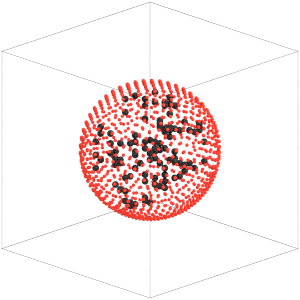

In [13]:
render(sim.state.get_snapshot())

### Describe rods as rigid bodies

In [14]:
rigid = hoomd.md.constrain.Rigid()
rigid.body["A"] = {
    "constituent_types":['A_const','A_const','A_const','A_const'],
    "positions": [(sigma,0,0), (0.5*sigma,0,0), (-0.5*sigma,0,0), (-sigma,0,0)],
    "orientations":[(1,0,0,0),(1,0,0,0),(1,0,0,0),(1,0,0,0)]
}
rigid.create_bodies(sim.state)

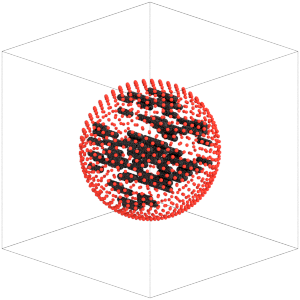

In [15]:
render(sim.state.get_snapshot())

### Set up Langevin integrator:

In [16]:
filter_all = hoomd.filter.All()
filter_mesh = hoomd.filter.Type(['mesh'])
filter_free = hoomd.filter.Rigid(("center","free"))

In [17]:
integrator = hoomd.md.Integrator(dt=dt,rigid=rigid, integrate_rotational_dof=True)
sim.operations.integrator = integrator

#integrate only free particles
langevin = hoomd.md.methods.Langevin(filter=filter_free, kT=kT)
langevin.gamma['mesh'] = mesh_gamma
langevin.gamma['A'] = gamma
langevin.gamma_r['A'] = gamma_r
integrator.methods.append(langevin)

### Write timesteps:

In [18]:
#custom_action = PrintTimestep()
#custom_op = hoomd.write.CustomWriter(action=custom_action, trigger=hoomd.trigger.Periodic(500))

### Create the Simulation Mesh
- I need to find the particle tags of the particles that make up the vertices of each triangle in the triangulation.
  - To do so I will list the faces resulting from the delauney triangulation and make a list of the cartesian coordinates of each vertex on each triangle face.
  - Then, I will find which particle ID each corresponds to.
- Then, I need to pass this list into the hoomd.mesh.Mesh() data structure.
  - https://hoomd-blue.readthedocs.io/en/v4.7.0/module-hoomd-mesh.html#hoomd.mesh.Mesh
  - See mesh visualization in mesh notebook
    

In [19]:
mesh = pv.PolyData(mesh_position)

# Delaunay triangulation and surface extraction:
triangulated = mesh.delaunay_3d()
surface = triangulated.extract_geometry()
faces = surface.faces.reshape((-1, 4))
triangle_points = []

for face in faces:
    if face[0] == 3:  # Check that the face is a triangle
        triangle_points.append(face[1:])

triangle_tags = np.vstack((triangle_points))
N_triangles = len(triangle_tags)

In [20]:
mesh_obj = hoomd.mesh.Mesh()
mesh_obj.types = ["mesh"]
mesh_obj.triangulation = dict(type_ids = [0] * N_triangles,
      triangles = triangle_tags)

### I need to now apply the tether potential to the mesh. 
- Using $hoomd.md.mesh.bond.Tether(mesh)$
  - https://hoomd-blue.readthedocs.io/en/v4.7.0/module-md-mesh-bond.html
  - https://hoomd-blue.readthedocs.io/en/v4.7.0/module-md-bond.html#hoomd.md.bond.Tether
- Need to figure out what my l_min, l_c1, l_c0, and l_max should be
  - Be careful that the distance between tethers should fall between l_C0 and l_C1 or else the sim could blow up.
  - I will find the largest and smallest distance between any two points in any of these triangles because these will help me decide my bounds for how I define l_c0 and l_c1
  - Also! Make sure that l_min and l_c1 are not negative

In [21]:
triangle_cartesian_positions = frame.particles.position[triangle_tags]
global_max_edge = np.linalg.norm(triangle_cartesian_positions[:,0]-triangle_cartesian_positions[:,2],axis=1).max()
global_min_edge = np.linalg.norm(triangle_cartesian_positions[:,0]-triangle_cartesian_positions[:,2],axis=1).min()

#### Define tethering bond energy:

working Qs: 
- How to determine values of l_min, max, c0 and c1?
- Why the +0.003 and +0.002 to make symm??

In [22]:
avg_edge_len = (global_max_edge + global_min_edge+0.003)/2 + 0.001#plot is very sensitive to this

l_min=(2/3)*avg_edge_len
l_c1=0.85*avg_edge_len
l_c0=1.15*avg_edge_len
l_max=(4/3)*avg_edge_len 

tether_bond_params = [l_min, l_c1, l_c0, l_max, k_bond]
#plot_tether_energies(tether_bond_params)

#### Add bonding potential to mesh

In [23]:
mesh_bond_potential = hoomd.md.mesh.bond.Tether(mesh_obj)
mesh_bond_potential.params["mesh"] = dict(k_b=k_bond, l_min=l_min, l_c1=l_c1,
                                 l_c0=l_c0, l_max=l_max)
integrator.forces.append(mesh_bond_potential)

#### WCA potential between all particles

In [24]:
cell = hoomd.md.nlist.Cell(buffer=0.4, exclusions=['meshbond'])
#cell = hoomd.md.nlist.Cell(buffer=ideal_buffer,mesh=mesh,exclusions=("meshbond",))

In [25]:
lj = hoomd.md.pair.LJ(nlist=cell,mode="shift")
lj.params[('mesh','mesh'),('mesh','A'),('mesh','A_const'),('A','A'),('A_const','A'),('A_const','A_const')] = dict(epsilon=1, sigma=sigma)
lj.r_cut[('mesh','mesh'),('mesh','A'),('mesh','A_const'),('A','A'),('A_const','A'),('A_const','A_const')] = 2**(1.0/6.)*sigma
integrator.forces.append(lj)

#### Add bending potential to mesh (Helfrich bending potential)

In [26]:
helfrich_potential = hoomd.md.mesh.bending.Helfrich(mesh_obj)
helfrich_potential.params["mesh"] = dict(k=k_bend)
integrator.forces.append(helfrich_potential)

#### Area conservation of triangle meshes:

In [27]:
#TriArea = (np.sqrt(3) / 2) * sigma**2
#AvgR, stdR = find_radius_and_deviation(sim)
TriArea = 4*np.pi*10.6**2/len(faces) # Area of triangle = surface area of mesh / number of triangles
area_potential = hoomd.md.mesh.conservation.TriangleArea(mesh_obj)
area_potential.params.default = dict(k=k_area,A0=TriArea)
integrator.forces.append(area_potential)

Note: current blows up if I allow area conservation with current settings

### Add active forces to rod centers

In [28]:
active = hoomd.md.force.Active(filter=hoomd.filter.Type(['A']))
active.active_force['A'] = (v0,0,0)
active.active_torque['A'] = (0,0,0)
integrator.forces.append(active)

### Run the Simulation!

GSD logger:

In [29]:
logger = hoomd.logging.Logger(['particle','constraint'])

# This gsd writer saves ALL particles
gsd_oper = hoomd.write.GSD(trigger=hoomd.trigger.Periodic(int(250)), filename='flexicle.gsd',logger=logger,mode='wb',dynamic=['momentum','property'],filter=filter_all)
# This gsd writer saves the mesh particles
#gsd_oper = hoomd.write.GSD(trigger=hoomd.trigger.Periodic(int(50)), filename='mesh.gsd',logger=logger,mode='wb',dynamic=['momentum','property'],filter=filter_mesh)

sim.operations += gsd_oper

slowly increase area conservation strength to prevent simulation to blow up

In [30]:
while k_area < 10000:
    print(k_area)
    sim.run(5000)
    k_area *= 2
    area_potential.params.default = dict(k=k_area,A0=TriArea)
area_potential.params.default = dict(k=10000,A0=TriArea)
sim.run(10000)

1000
2000
4000
8000


Initialize the system:

radius:  10.698065830195912  and std:  1.485394599618002


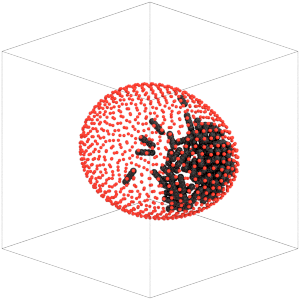

In [31]:
sim.state.thermalize_particle_momenta(filter=filter_all, kT=kT)
sim.run(0)
Ravg, Rstd  = find_mesh_radius_avg_and_std(sim)
print('radius: ', Ravg,' and std: ', Rstd)
render(sim.state.get_snapshot())

In [32]:
sim.timestep

30000

Thermalize the system!

radius:  11.23169978592754  and std:  2.157540686079347


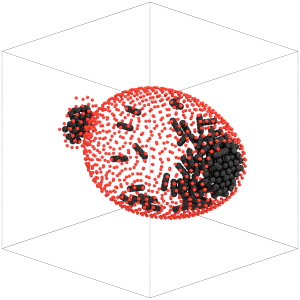

In [33]:
sim.run(10000)
gsd_oper.flush()
Ravg, Rstd  = find_mesh_radius_avg_and_std(sim)
print('radius: ', Ravg,' and std: ', Rstd)
render(sim.state.get_snapshot())

In [34]:
gsd_oper.flush()

radius:  10.062310356405147  and std:  4.746344336293287


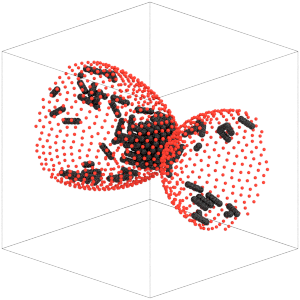

In [35]:
sim.run(100000)
gsd_oper.flush()
Ravg, Rstd  = find_mesh_radius_avg_and_std(sim)
print('radius: ', Ravg,' and std: ', Rstd)
render(sim.state.get_snapshot())

In [36]:
'''
sim.run(1000000)
gsd_oper.flush()
Ravg, Rstd  = find_mesh_radius_avg_and_std(sim)
print('radius: ', Ravg,' and std: ', Rstd)
render(sim.state.get_snapshot())
'''

"\nsim.run(1000000)\ngsd_oper.flush()\nRavg, Rstd  = find_mesh_radius_avg_and_std(sim)\nprint('radius: ', Ravg,' and std: ', Rstd)\nrender(sim.state.get_snapshot())\n"

In [37]:
gsd_oper.flush()

woohooooooo look at 'em  flyyyyy

:wq